In [58]:
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.metrics import roc_auc_score

# load Data set
df = pd.read_csv("../../data/features.csv")

# Feature matrix (multiple numeric features)
x = df[["A_asymmetry", "B_compactness", "C_hue", "C_saturation", "C_brightness"]]

# Ground Truth labels
y = df["Cancer"]

In [59]:
from sklearn.preprocessing import LabelEncoder

# Encode the categorical labels into numeric values
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [60]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(
    x, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [61]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(
    criterion="gini",      # or "entropy"          
    max_depth=5,           # prevents overfitting
    min_samples_leaf=5,
    random_state=42
)

decision_tree.fit(x_train, y_train)

print(f"Train accuracy: {decision_tree.score(x_train,y_train)}")
print(f"Mean accuracy: {decision_tree.score(x_test,y_test)}")

Train accuracy: 0.7117718446601942
Mean accuracy: 0.6319612590799032


In [ ]:
#Evaluate with different maximum depth for trees
max_depth_metrics = {"train":[], "test":[]}
max_depth_auc = {"train": [], "test": []}


depths = [1, 5, 10, 20, None]

print("\nEvaluating max_depth:")
for depth in depths:
    random_forest = RandomForestClassifier(
        n_estimators=100,
        max_depth=depth,
        random_state=1907
    )
    random_forest.fit(x_train, y_train)

    # ---------- Accuracy ----------
    train_acc = random_forest.score(x_train, y_train)
    test_acc = random_forest.score(x_test, y_test)

    max_depth_metrics["train"].append(train_acc)
    max_depth_metrics["test"].append(test_acc)

    # ---------- AUC ----------
    train_probs = random_forest.predict_proba(x_train)[:, 1]
    test_probs = random_forest.predict_proba(x_test)[:, 1]

    train_auc = roc_auc_score(y_train, train_probs)
    test_auc = roc_auc_score(y_test, test_probs)

    max_depth_auc["train"].append(train_auc)
    max_depth_auc["test"].append(test_auc)

    print(
        f"max_depth={depth} | "
        f"train_acc={train_acc:.3f}, test_acc={test_acc:.3f} | "
        f"train_auc={train_auc:.3f}, test_auc={test_auc:.3f}"
    )


Evaluating max_depth:
max_depth=1 | train_acc=0.674, test_acc=0.639 | train_auc=0.738, test_auc=0.658
max_depth=5 | train_acc=0.737, test_acc=0.654 | train_auc=0.837, test_auc=0.696
max_depth=10 | train_acc=0.914, test_acc=0.649 | train_auc=0.978, test_auc=0.700
max_depth=20 | train_acc=1.000, test_acc=0.632 | train_auc=1.000, test_auc=0.691
max_depth=None | train_acc=1.000, test_acc=0.639 | train_auc=1.000, test_auc=0.688


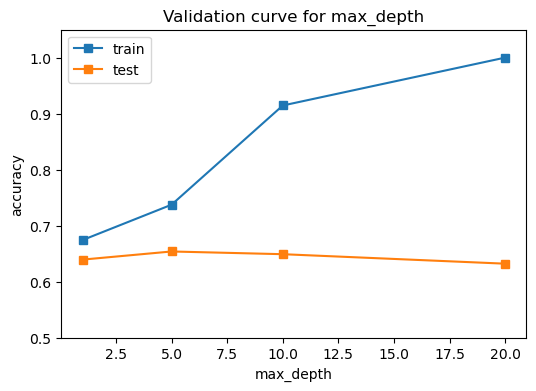

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(depths, max_depth_metrics["train"], marker='s', label="train")
ax.plot(depths, max_depth_metrics["test"], marker='s', label="test")

ax.set_ylim(0.5, 1.05)
ax.set_xlabel("max_depth")
ax.set_ylabel("accuracy")
ax.set_title("Validation curve for max_depth")
ax.legend()

plt.show()

